In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Load dataset
df = pd.read_csv(r"dataset.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Sort properly
df = df.sort_values(by='Date')

# View data
df.head(10)

,Date,Product_Name,Category,Monthly_Sales,Unit_Price,Revenue,Rainfall_Index,Industrial_Index,Diesel_Price,Steel_Price,Govt_Subsidy_Flag,Festival_Flag
0,2020-02-01,Tractor Linkage Balls,Tractor,310,1544.40,478763.18,128.70,98.15,63.20,54.48,0,0
426,2020-02-01,CNC Parts Assembly,CNC,433,2059.29,891671.19,129.07,99.38,65.94,47.66,0,0
71,2020-02-01,Tractor Linkage Ends,Tractor,312,1698.74,530006.37,128.98,101.42,65.08,54.75,0,0
213,2020-02-01,Front Bumper Tractor,Tractor,359,1777.33,638059.72,127.71,93.64,65.44,48.07,0,0
142,2020-02-01,Linkage Pins,Tractor,369,1291.41,476530.81,139.78,99.35,64.52,52.48,0,0
284,2020-02-01,Tractor Front Axle Bracket,Tractor,521,1386.87,722557.47,124.94,97.45,64.13,51.37,0,0
355,2020-02-01,CNC Machine Parts,CNC,448,2212.24,991085.68,123.53,101.54,64.75,52.65,0,0
72,2020-03-01,Tractor Linkage Ends,Tractor,292,1684.09,491755.73,125.51,106.38,65.90,51.82,0,0
214,2020-03-01,Front Bumper Tractor,Tractor,358,1783.47,638480.77,135.54,98.68,66.27,49.29,0,0
427,2020-03-01,CNC Parts Assembly,CNC,438,2069.55,906464.14,124.58,105.96,65.45,49.71,0,0


In [16]:
df.shape

(497, 12)

In [17]:
df.columns

Index(['Date', 'Product_Name', 'Category', 'Monthly_Sales', 'Unit_Price',
       'Revenue', 'Rainfall_Index', 'Industrial_Index', 'Diesel_Price',
       'Steel_Price', 'Govt_Subsidy_Flag', 'Festival_Flag'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 497 entries, 0 to 496
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               497 non-null    datetime64[ns]
 1   Product_Name       497 non-null    object        
 2   Category           497 non-null    object        
 3   Monthly_Sales      497 non-null    int64         
 4   Unit_Price         497 non-null    float64       
 5   Revenue            497 non-null    float64       
 6   Rainfall_Index     497 non-null    float64       
 7   Industrial_Index   497 non-null    float64       
 8   Diesel_Price       497 non-null    float64       
 9   Steel_Price        497 non-null    float64       
 10  Govt_Subsidy_Flag  497 non-null    int64         
 11  Festival_Flag      497 non-null    int64         
dtypes: datetime64[ns](1), float64(6), int64(3), object(2)
memory usage: 50.5+ KB


In [19]:
df.isnull().sum()

Date                 0
Product_Name         0
Category             0
Monthly_Sales        0
Unit_Price           0
Revenue              0
Rainfall_Index       0
Industrial_Index     0
Diesel_Price         0
Steel_Price          0
Govt_Subsidy_Flag    0
Festival_Flag        0
dtype: int64

In [20]:
df['Product_Name'].unique()

array(['Tractor Linkage Balls', 'CNC Parts Assembly',
       'Tractor Linkage Ends', 'Front Bumper Tractor', 'Linkage Pins',
       'Tractor Front Axle Bracket', 'CNC Machine Parts'], dtype=object)

In [21]:
product = "Tractor Linkage Balls"

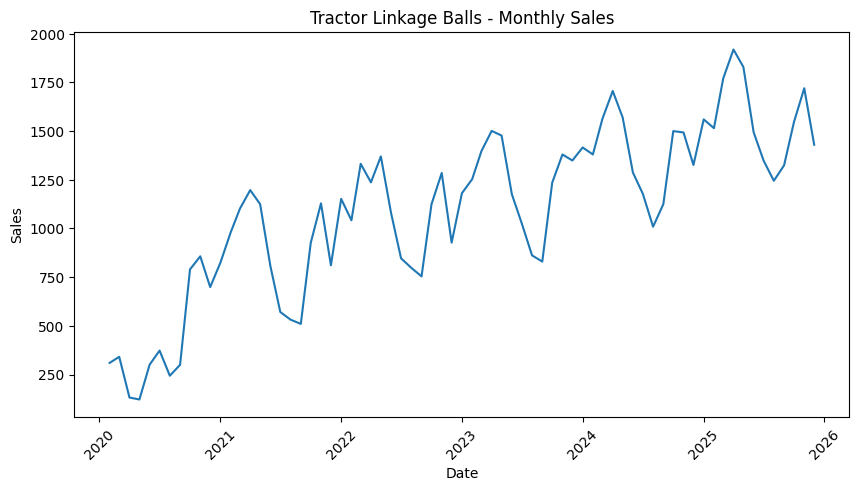

In [22]:
df_p = df[df['Product_Name'] == product].copy()

df_p = df_p.sort_values(by='Date')
df_p.set_index('Date', inplace=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_p['Monthly_Sales'])
plt.title(product + " - Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

The time series shows a clear seasonal pattern with recurring peaks aligned to agricultural cycles, along with a noticeable dip during the COVID period.

### Decomposition
    - Trend
    - Seasonality
    - Residual (noise)

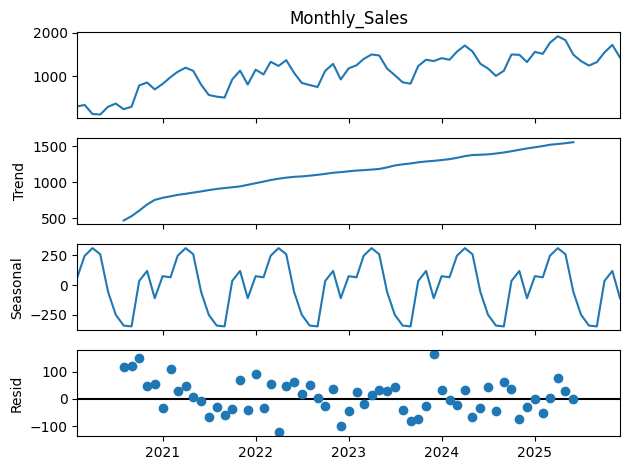

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_p['Monthly_Sales'], model='additive', period=12)

result.plot()
plt.show()

### ADF Test (Season)

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_p['Monthly_Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6522592037303334
p-value: 0.45586245079920873


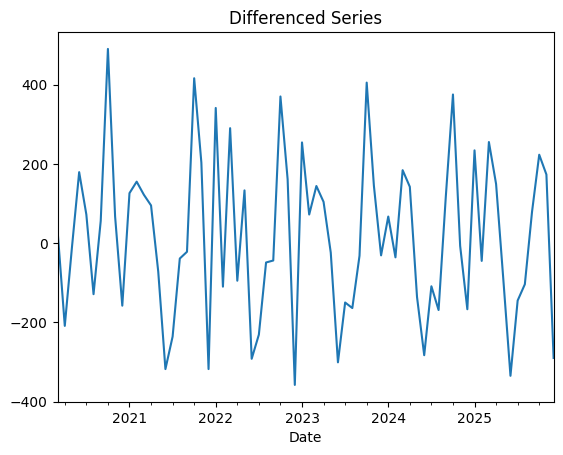

In [25]:
# Differencing
df_p['diff'] = df_p['Monthly_Sales'].diff()

df_p['diff'].dropna().plot()
plt.title("Differenced Series")
plt.show()

In [26]:
result = adfuller(df_p['diff'].dropna())

print("New p-value:", result[1])

New p-value: 0.008144810423887254


The original series was non-stationary with p-value greater than 0.05. After applying first-order differencing, the series became stationary with p-value less than 0.05, making it suitable for ARIMA-based modeling. (used ADF test)

### ACF & PACF (MODEL SELECTION)

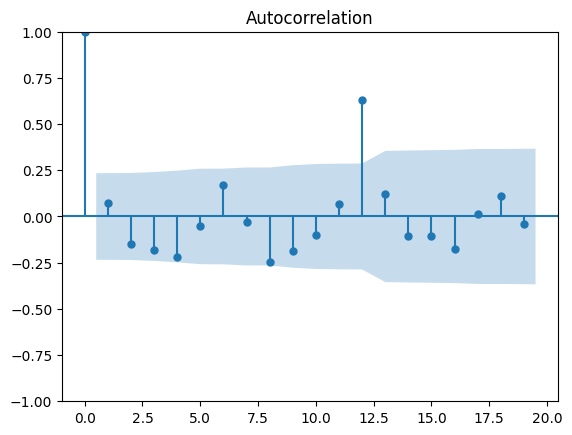

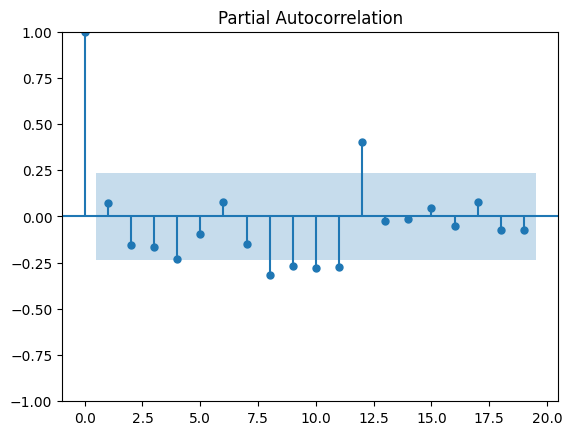

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_p['diff'].dropna())
plot_pacf(df_p['diff'].dropna())
plt.show()

ACF and PACF plots show significant spikes at lag 12, indicating strong annual seasonality in the data. Short-term lags are weak, so a simple ARIMA structure with seasonal components is appropriate.

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_p.iloc[:-12]
test = df_p.iloc[-12:]

exog_train = train[['Rainfall_Index', 'Diesel_Price', 'Govt_Subsidy_Flag']]
exog_test = test[['Rainfall_Index', 'Diesel_Price', 'Govt_Subsidy_Flag']]

model = SARIMAX(train['Monthly_Sales'],
                exog=exog_train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit(disp=False)

print("Model trained successfully")

C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
 

Model trained successfully


C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Forecast and Compare

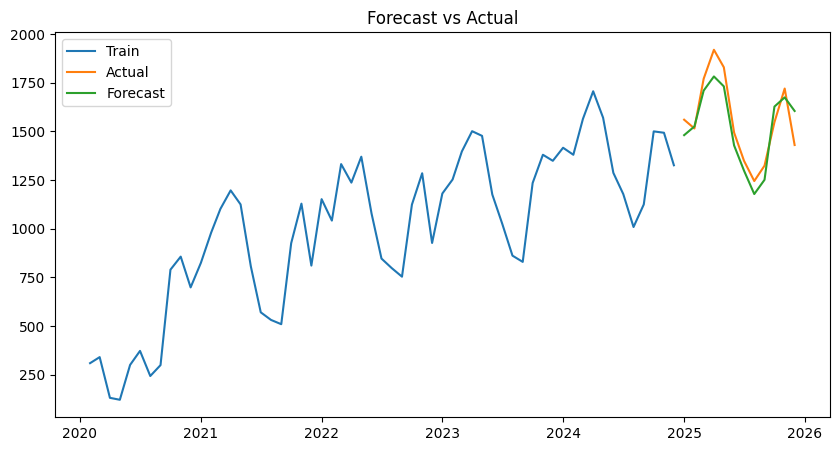

In [31]:
forecast = model_fit.forecast(steps=12, exog=exog_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train.index, train['Monthly_Sales'], label='Train')
plt.plot(test.index, test['Monthly_Sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title("Forecast vs Actual")
plt.legend()
plt.show()

### Next Accuracy

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Monthly_Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Monthly_Sales'], forecast))
mape = np.mean(np.abs((test['Monthly_Sales'] - forecast) / test['Monthly_Sales'])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 78.45081460535988
RMSE: 88.55754848080072
MAPE: 5.061261290135756


The model achieved a MAPE of approximately 5%, indicating highly accurate forecasts. This validates the effectiveness of SARIMAX with external variables for modeling seasonal agricultural demand.

## CNC Machine Parts

In [4]:
product = "CNC Machine Parts"

df_cnc = df[df["Product_Name"] == product].copy()
df_cnc = df_cnc.sort_values("Date")
df_cnc.set_index("Date", inplace=True)

print(df_cnc.head())
print(df_cnc.shape)

                 Product_Name Category  Monthly_Sales  Unit_Price     Revenue  \
Date                                                                            
2020-02-01  CNC Machine Parts      CNC            448     2212.24   991085.68   
2020-03-01  CNC Machine Parts      CNC            437     2206.07   964051.73   
2020-04-01  CNC Machine Parts      CNC            169     2209.57   373417.07   
2020-05-01  CNC Machine Parts      CNC            155     3169.31   491243.54   
2020-06-01  CNC Machine Parts      CNC            513     3157.54  1619816.85   

            Rainfall_Index  Industrial_Index  Diesel_Price  Steel_Price  \
Date                                                                      
2020-02-01          123.53            101.54         64.75        52.65   
2020-03-01          131.16            104.54         63.64        51.41   
2020-04-01          120.61            104.23         68.23        52.11   
2020-05-01          102.74            110.07         65.7

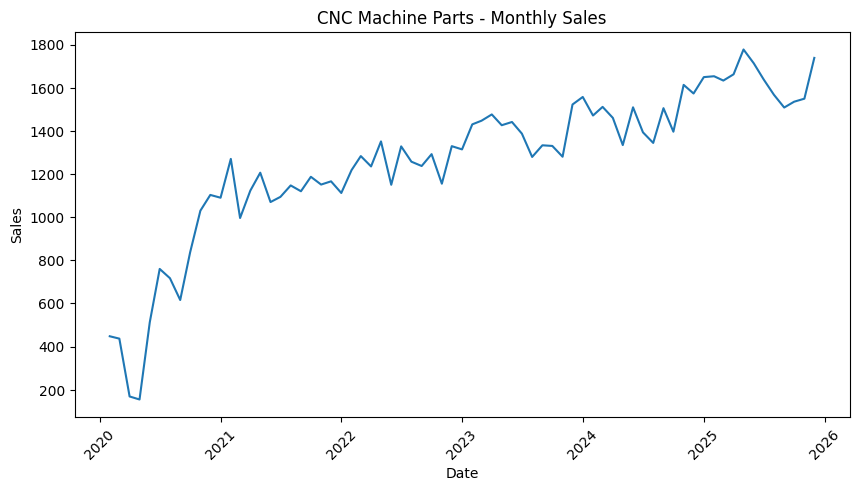

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df_cnc.index, df_cnc["Monthly_Sales"])
plt.title(product + " - Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

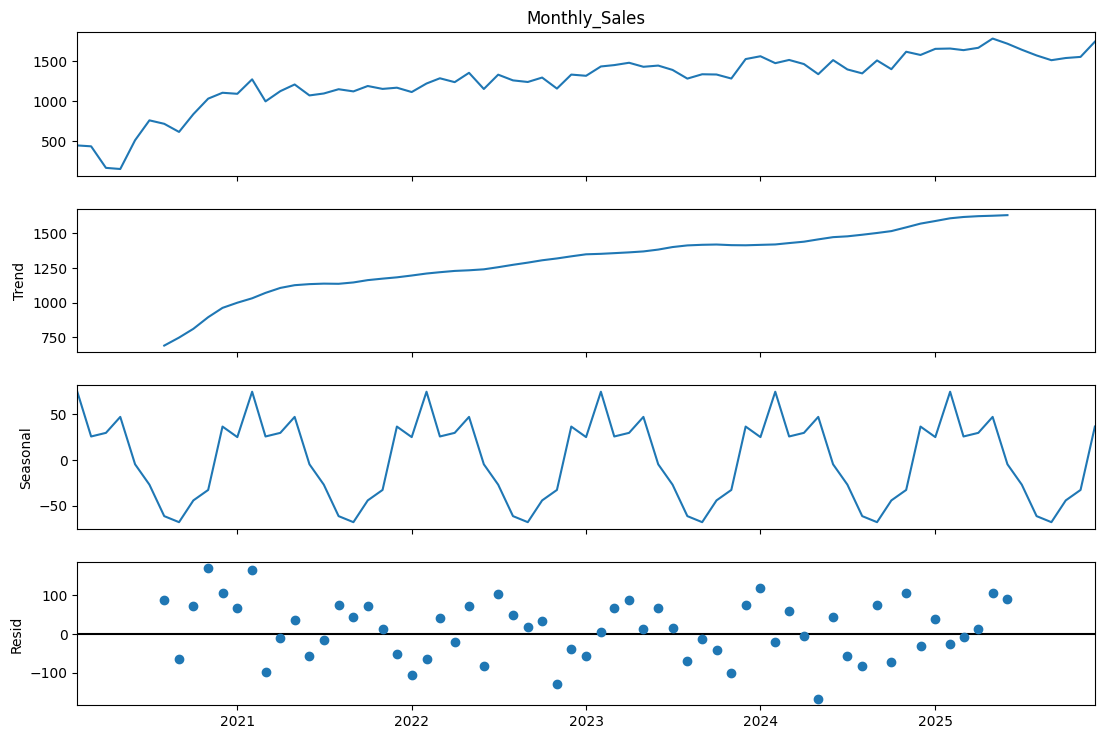

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(df_cnc["Monthly_Sales"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_cnc["Monthly_Sales"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.9412525346590102
p-value: 0.3129102558964766


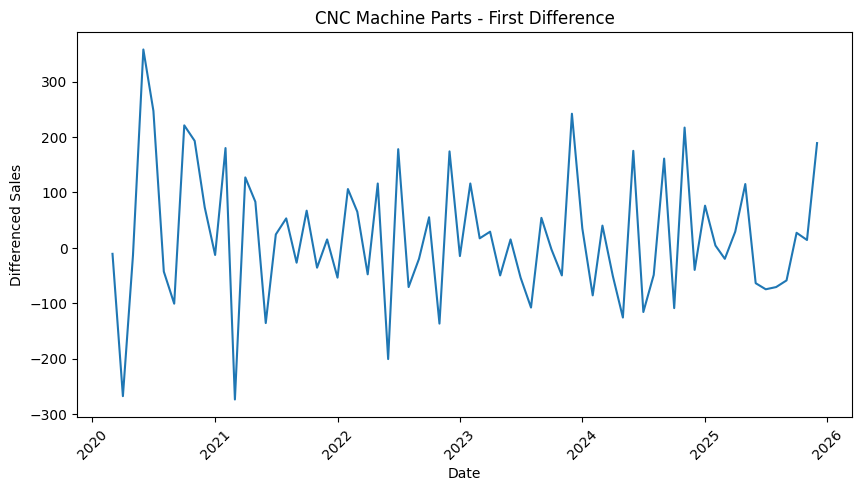

In [8]:
df_cnc["Sales_Diff"] = df_cnc["Monthly_Sales"].diff()

plt.figure(figsize=(10,5))
plt.plot(df_cnc.index, df_cnc["Sales_Diff"])
plt.title("CNC Machine Parts - First Difference")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.xticks(rotation=45)
plt.show()

In [10]:
result_diff = adfuller(df_cnc["Sales_Diff"].dropna())
print("New ADF Statistic:", result_diff[0])
print("New p-value:", result_diff[1])

New ADF Statistic: -2.911666335276199
New p-value: 0.044008083742001596


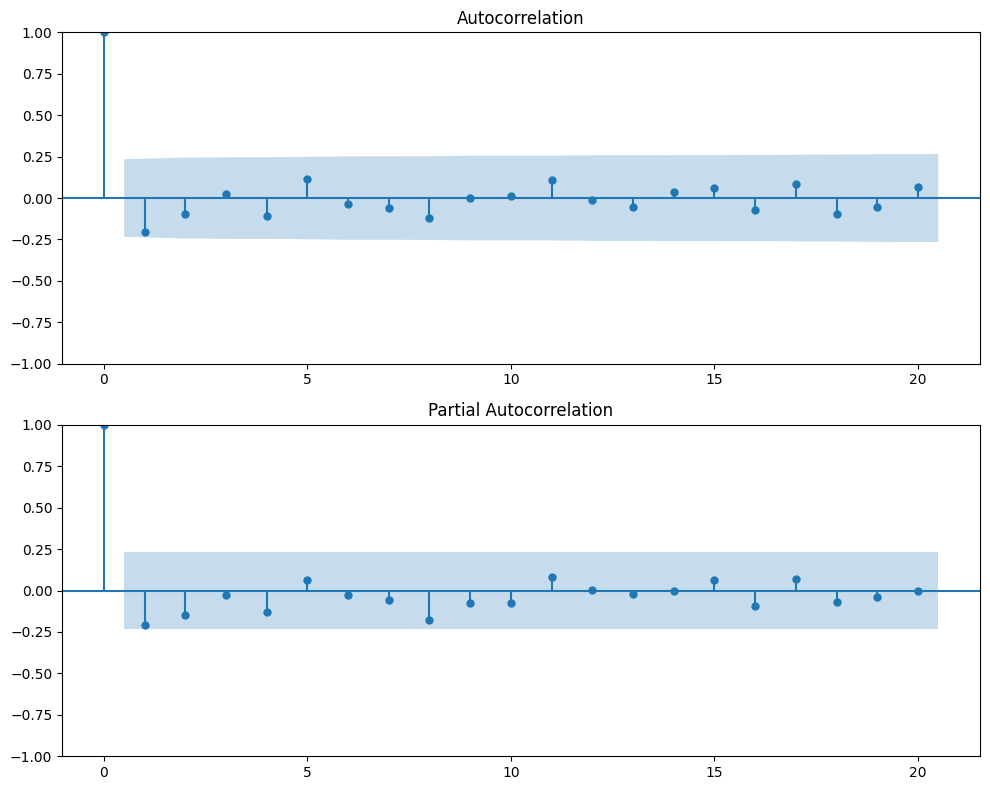

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(df_cnc["Sales_Diff"].dropna(), lags=20, ax=ax[0])
plot_pacf(df_cnc["Sales_Diff"].dropna(), lags=20, ax=ax[1])
plt.tight_layout()
plt.show()

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_cnc.iloc[:-12]
test = df_cnc.iloc[-12:]

exog_train = train[["Industrial_Index", "Steel_Price"]]
exog_test = test[["Industrial_Index", "Steel_Price"]]

model_cnc = SARIMAX(
    train["Monthly_Sales"],
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(0,0,0,0)
)

model_cnc_fit = model_cnc.fit(disp=False)

print("CNC model trained successfully")

C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


CNC model trained successfully


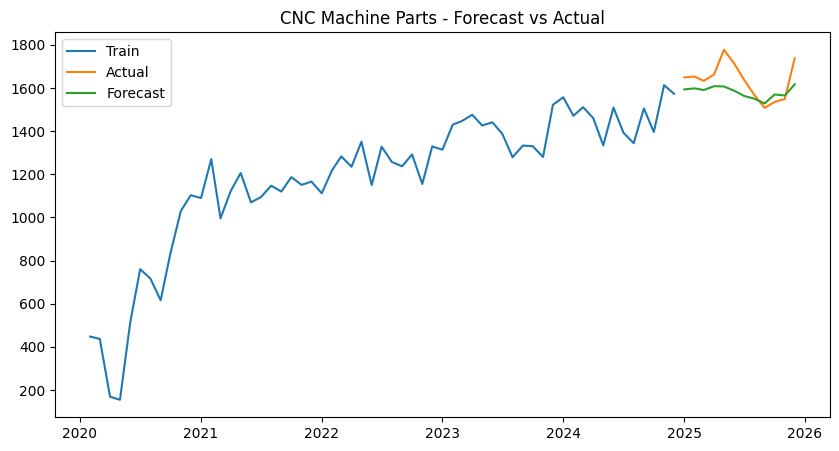

In [14]:
forecast_cnc = model_cnc_fit.forecast(steps=12, exog=exog_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train.index, train["Monthly_Sales"], label="Train")
plt.plot(test.index, test["Monthly_Sales"], label="Actual")
plt.plot(test.index, forecast_cnc, label="Forecast")
plt.title("CNC Machine Parts - Forecast vs Actual")
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Monthly_Sales"], forecast_cnc)
rmse = np.sqrt(mean_squared_error(test["Monthly_Sales"], forecast_cnc))
mape = np.mean(np.abs((test["Monthly_Sales"] - forecast_cnc) / test["Monthly_Sales"])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 65.58744763012953
RMSE: 80.63441227701671
MAPE: 3.8946733960235855


In [33]:
print(model_fit.summary())        # tractor model
print(model_cnc_fit.summary())    # cnc model

                                     SARIMAX Results                                      
Dep. Variable:                      Monthly_Sales   No. Observations:                   59
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -291.742
Date:                            Wed, 18 Mar 2026   AIC                            599.483
Time:                                    15:21:45   BIC                            614.112
Sample:                                02-01-2020   HQIC                           604.963
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Rainfall_Index       -0.1342      3.250     -0.041      0.967      -6.504       6.236
Diesel_Price  

In [35]:
product = "Tractor Linkage Balls"

df_product = df[df["Product_Name"] == product].copy()
df_product = df_product.sort_values("Date")
df_product.set_index("Date", inplace=True)

print(df_product.head())

                     Product_Name Category  Monthly_Sales  Unit_Price  \
Date                                                                    
2020-02-01  Tractor Linkage Balls  Tractor            310     1544.40   
2020-03-01  Tractor Linkage Balls  Tractor            341     1524.31   
2020-04-01  Tractor Linkage Balls  Tractor            132     1507.85   
2020-05-01  Tractor Linkage Balls  Tractor            122     1325.92   
2020-06-01  Tractor Linkage Balls  Tractor            301     1321.65   

              Revenue  Rainfall_Index  Industrial_Index  Diesel_Price  \
Date                                                                    
2020-02-01  478763.18          128.70             98.15         63.20   
2020-03-01  519788.09          125.36            106.54         66.50   
2020-04-01  199035.93          123.66            102.20         66.06   
2020-05-01  161762.21          112.19            102.36         66.52   
2020-06-01  397817.70          101.11            1

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_product.iloc[:-12]
test = df_product.iloc[-12:]

sarima_model = SARIMAX(
    train["Monthly_Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit(disp=False)

forecast_sarima = sarima_fit.forecast(steps=12)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Monthly_Sales"], forecast_sarima)
rmse = np.sqrt(mean_squared_error(test["Monthly_Sales"], forecast_sarima))
mape = np.mean(np.abs((test["Monthly_Sales"] - forecast_sarima) / test["Monthly_Sales"])) * 100

print("SARIMA Tractor MAPE:", mape)

C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA Tractor MAPE: 3.793928413061424


In [38]:
train = df_cnc.iloc[:-12]
test = df_cnc.iloc[-12:]

arima_model = SARIMAX(
    train["Monthly_Sales"],
    order=(1,1,1),
    seasonal_order=(0,0,0,0)
)

arima_fit = arima_model.fit(disp=False)
forecast_arima = arima_fit.forecast(steps=12)

mae = mean_absolute_error(test["Monthly_Sales"], forecast_arima)
rmse = np.sqrt(mean_squared_error(test["Monthly_Sales"], forecast_arima))
mape = np.mean(np.abs((test["Monthly_Sales"] - forecast_arima) / test["Monthly_Sales"])) * 100

print("ARIMA CNC MAPE:", mape)

C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Lakshita Joshi\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA CNC MAPE: 5.230985820726567


The study found that different product categories required different forecasting models. For Tractor Linkage Balls, the SARIMA model achieved better accuracy than SARIMAX, indicating that internal seasonal patterns were sufficient for forecasting. For CNC Machine Parts, ARIMAX outperformed ARIMA, showing that external variables contributed to improved forecast accuracy.

In [39]:
tractor_residuals = sarima_fit.resid
cnc_residuals = model_cnc_fit.resid

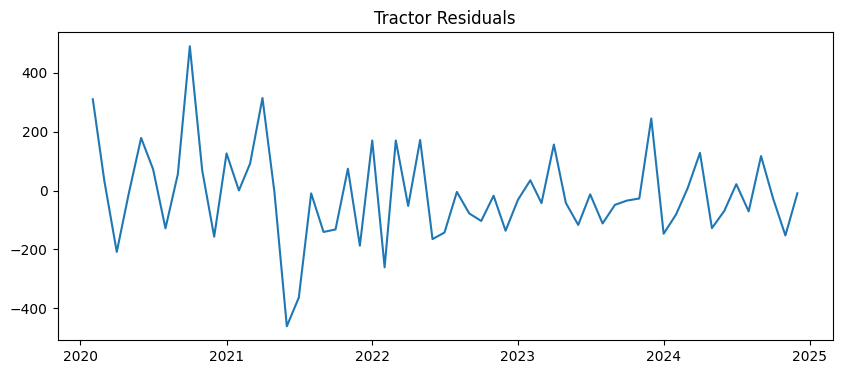

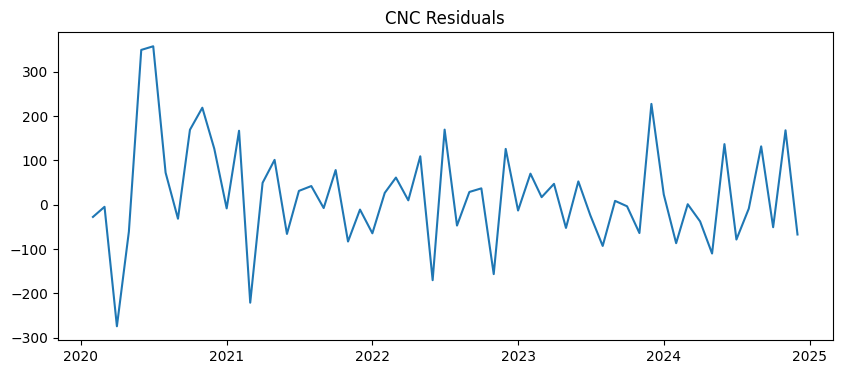

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(tractor_residuals)
plt.title("Tractor Residuals")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(cnc_residuals)
plt.title("CNC Residuals")
plt.show()

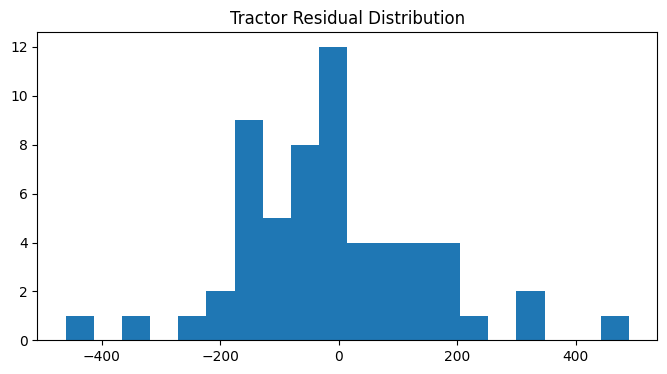

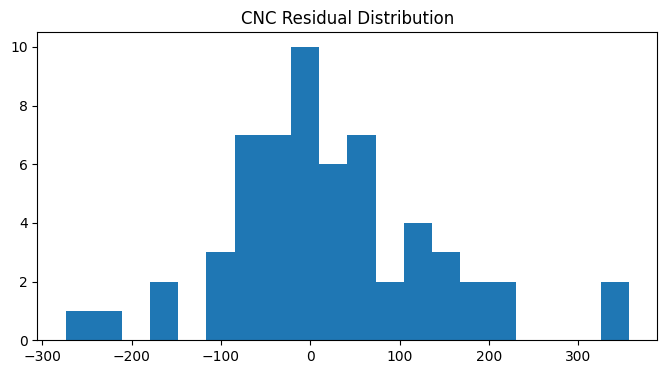

In [41]:
plt.figure(figsize=(8,4))
plt.hist(tractor_residuals, bins=20)
plt.title("Tractor Residual Distribution")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(cnc_residuals, bins=20)
plt.title("CNC Residual Distribution")
plt.show()

# EDA

In [2]:
## Dataset Overview

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nUnique Products:\n", df["Product_Name"].unique())
print("\nCategory Counts:\n", df["Category"].value_counts())
print("\nDate Range:", df["Date"].min(), "to", df["Date"].max())

Shape: (497, 12)

Columns:
 Index(['Date', 'Product_Name', 'Category', 'Monthly_Sales', 'Unit_Price',
       'Revenue', 'Rainfall_Index', 'Industrial_Index', 'Diesel_Price',
       'Steel_Price', 'Govt_Subsidy_Flag', 'Festival_Flag'],
      dtype='object')

Data Types:
 Date                 datetime64[ns]
Product_Name                 object
Category                     object
Monthly_Sales                 int64
Unit_Price                  float64
Revenue                     float64
Rainfall_Index              float64
Industrial_Index            float64
Diesel_Price                float64
Steel_Price                 float64
Govt_Subsidy_Flag             int64
Festival_Flag                 int64
dtype: object

Null Values:
 Date                 0
Product_Name         0
Category             0
Monthly_Sales        0
Unit_Price           0
Revenue              0
Rainfall_Index       0
Industrial_Index     0
Diesel_Price         0
Steel_Price          0
Govt_Subsidy_Flag    0
Festival_Flag  

## Summary Statistics

In [4]:
df.describe()

,Date,Monthly_Sales,Unit_Price,Revenue,Rainfall_Index,Industrial_Index,Diesel_Price,Steel_Price,Govt_Subsidy_Flag,Festival_Flag
count,497,497.000000,497.000000,4.970000e+02,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000
mean,2022-12-31 11:49:51.549295872,1193.074447,1927.199316,2.350755e+06,99.757907,162.882233,77.265392,59.075010,0.338028,0.169014
min,2020-02-01 00:00:00,122.000000,1130.690000,1.617622e+05,55.560000,93.640000,63.200000,37.020000,0.000000,0.000000
25%,2021-07-01 00:00:00,926.000000,1517.850000,1.554796e+06,79.030000,129.890000,70.800000,52.180000,0.000000,0.000000
50%,2023-01-01 00:00:00,1247.000000,1833.390000,2.241193e+06,96.980000,162.550000,77.150000,58.930000,0.000000,0.000000
75%,2024-07-01 00:00:00,1505.000000,2096.430000,3.102880e+06,120.860000,194.910000,83.320000,66.330000,1.000000,0.000000
max,2025-12-01 00:00:00,2388.000000,3310.350000,5.515334e+06,142.860000,230.460000,92.610000,78.360000,1.000000,1.000000
std,NaN,447.027671,542.910970,1.181605e+06,22.387550,37.197399,7.261391,9.017619,0.473515,0.375142


## Sales by Product

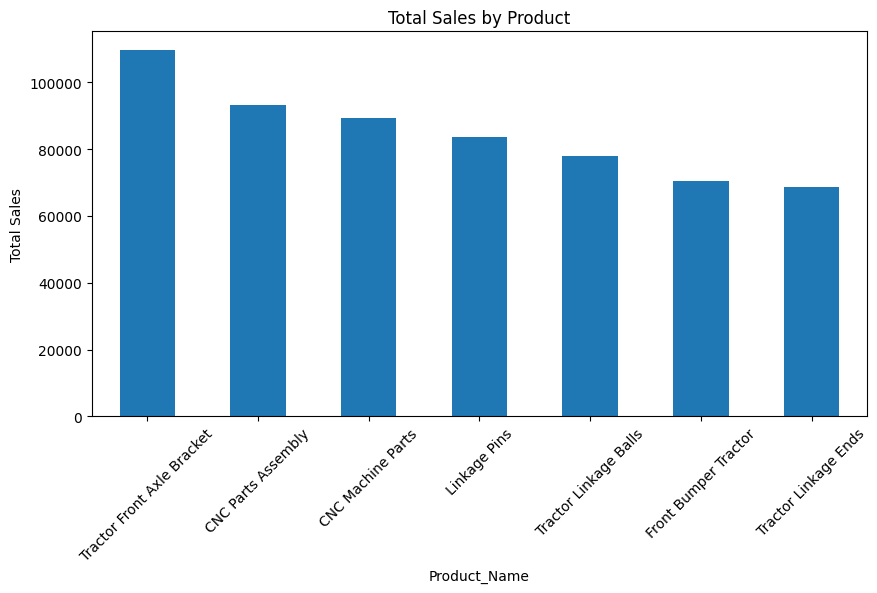

In [5]:
product_sales = df.groupby("Product_Name")["Monthly_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_sales.plot(kind="bar")
plt.title("Total Sales by Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## Revenue by Product

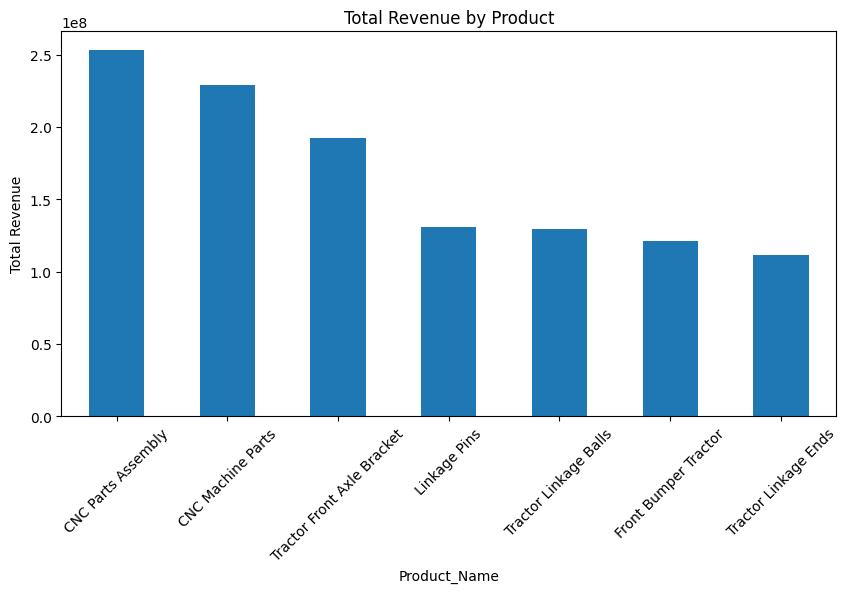

In [6]:
product_revenue = df.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_revenue.plot(kind="bar")
plt.title("Total Revenue by Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

## Sales by Category

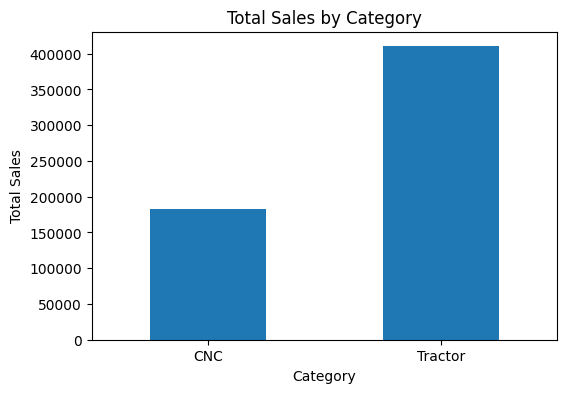

In [7]:
category_sales = df.groupby("Category")["Monthly_Sales"].sum()

plt.figure(figsize=(6,4))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

## Revenue by Category

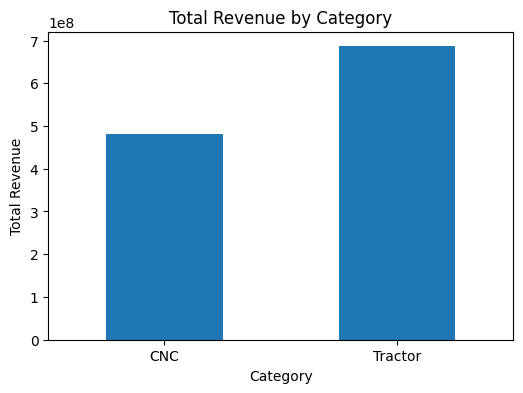

In [8]:
category_revenue = df.groupby("Category")["Revenue"].sum()

plt.figure(figsize=(6,4))
category_revenue.plot(kind="bar")
plt.title("Total Revenue by Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

## Monthly Sales Trend

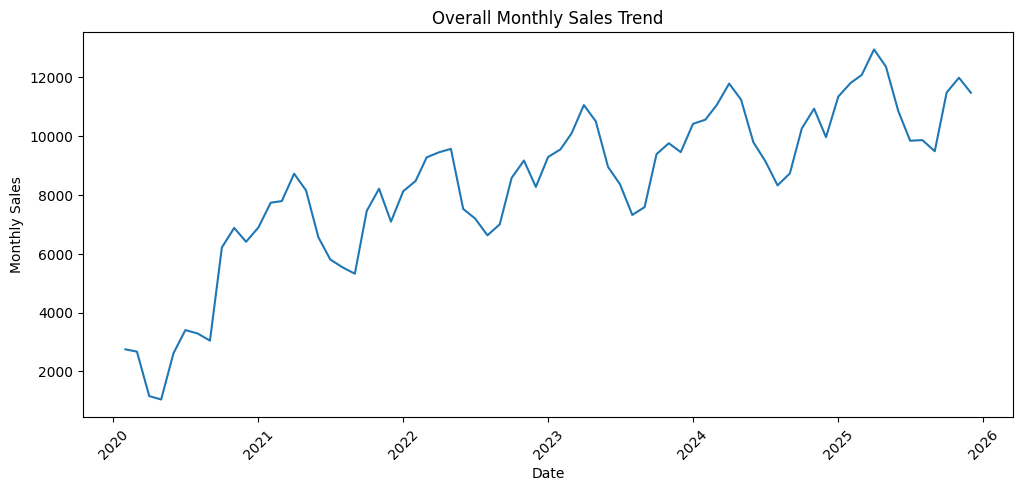

In [9]:
monthly_sales = df.groupby("Date")["Monthly_Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.show()

## Overall monthly revenue trend

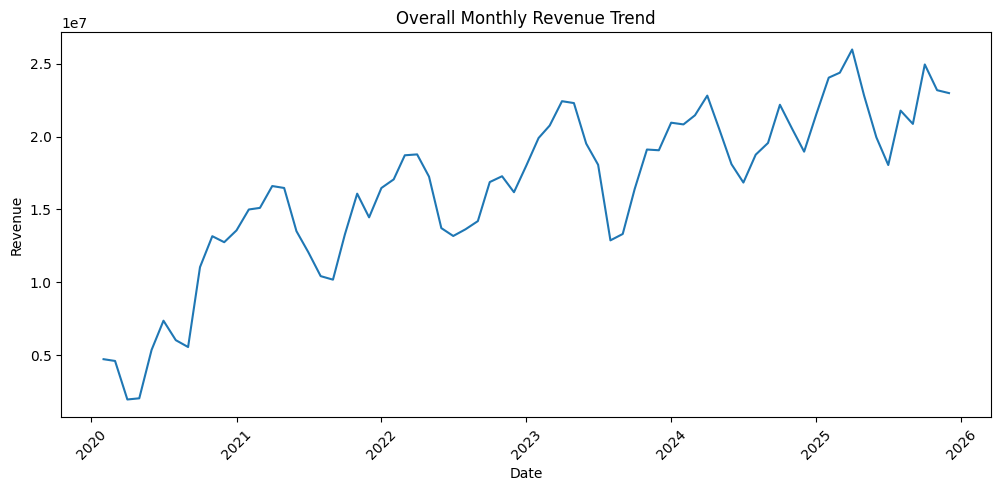

In [10]:
monthly_revenue = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.title("Overall Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Tractor vs CNC monthly sales trend

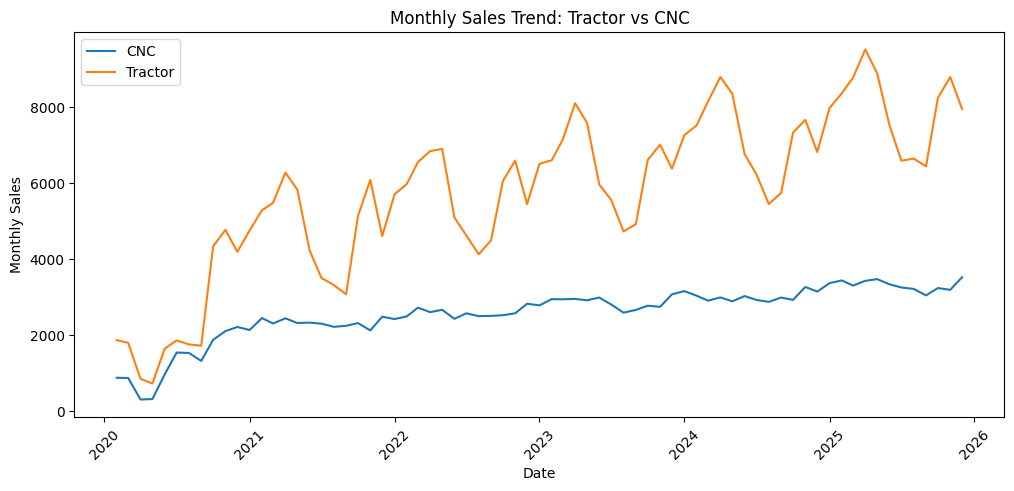

In [11]:
category_monthly = df.groupby(["Date", "Category"])["Monthly_Sales"].sum().unstack()

plt.figure(figsize=(12,5))
for col in category_monthly.columns:
    plt.plot(category_monthly.index, category_monthly[col], label=col)

plt.title("Monthly Sales Trend: Tractor vs CNC")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## External Variables Trend

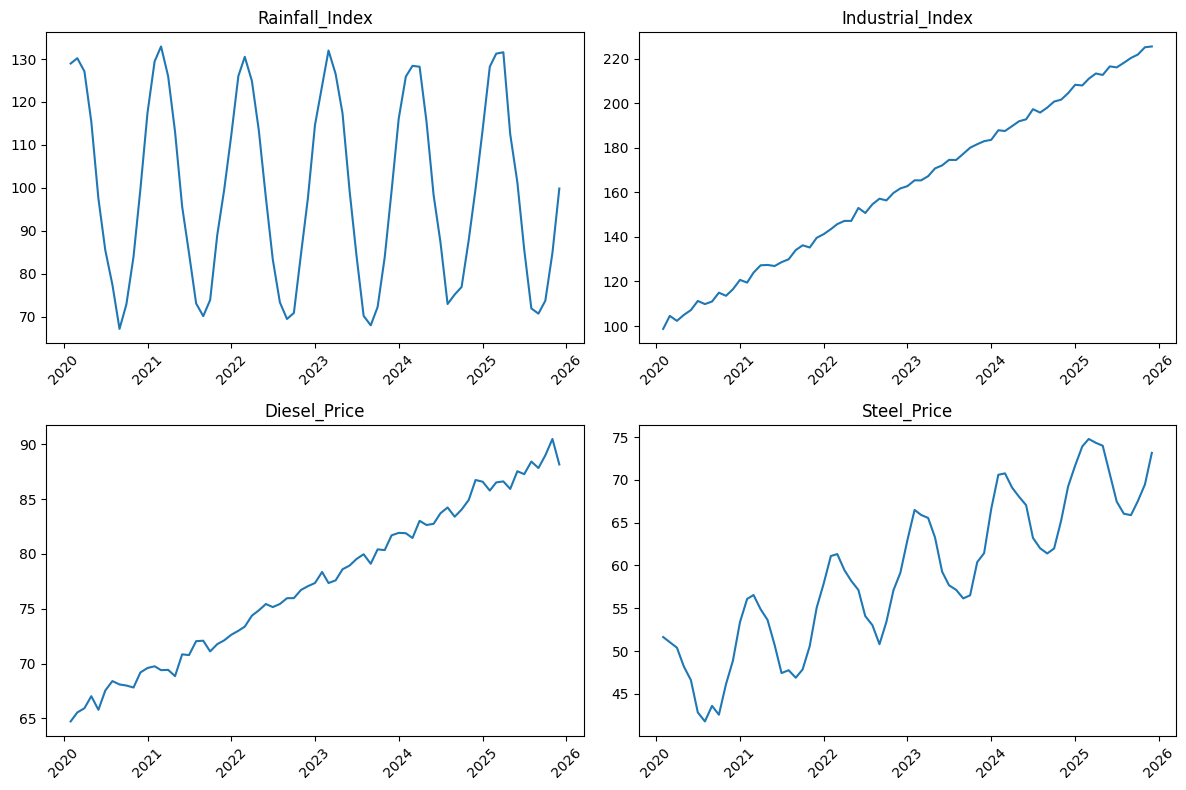

In [12]:
external_cols = ["Rainfall_Index", "Industrial_Index", "Diesel_Price", "Steel_Price"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, col in zip(axes.flatten(), external_cols):
    monthly_col = df.groupby("Date")[col].mean()
    ax.plot(monthly_col.index, monthly_col.values)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Correlation Heatmap

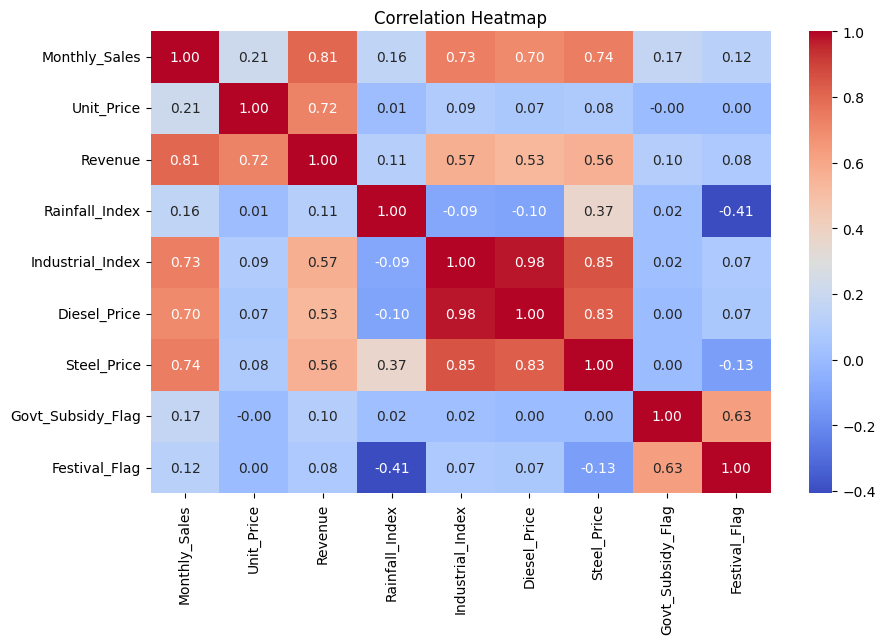

In [13]:
numeric_cols = [
    "Monthly_Sales", "Unit_Price", "Revenue",
    "Rainfall_Index", "Industrial_Index",
    "Diesel_Price", "Steel_Price",
    "Govt_Subsidy_Flag", "Festival_Flag"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Sales Distribution

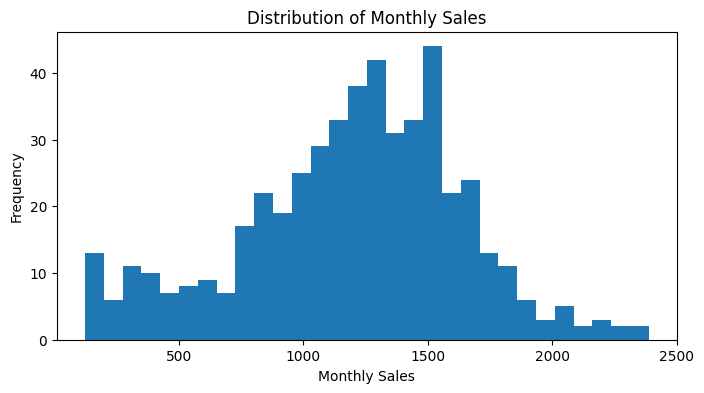

In [14]:
plt.figure(figsize=(8,4))
plt.hist(df["Monthly_Sales"], bins=30)
plt.title("Distribution of Monthly Sales")
plt.xlabel("Monthly Sales")
plt.ylabel("Frequency")
plt.show()

## Revenue Distribution

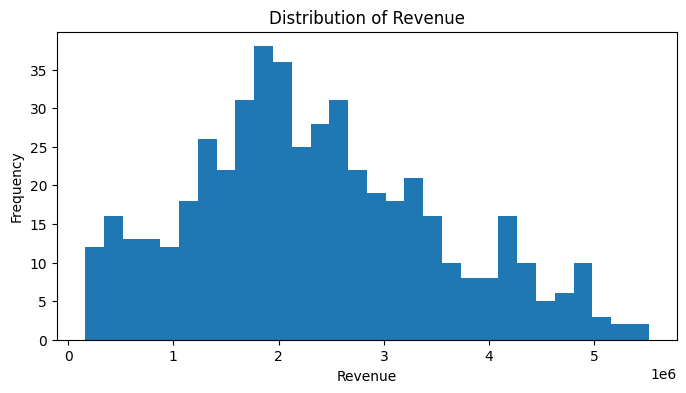

In [20]:
plt.figure(figsize=(8,4))
plt.hist(df["Revenue"], bins=30)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

## Sales vs Revenue

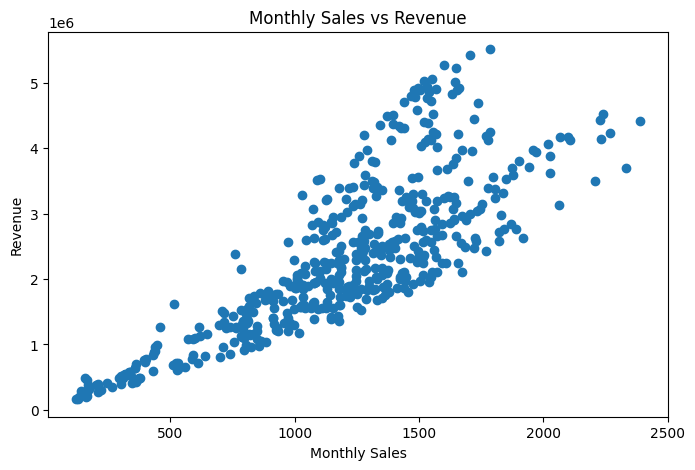

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["Monthly_Sales"], df["Revenue"])
plt.title("Monthly Sales vs Revenue")
plt.xlabel("Monthly Sales")
plt.ylabel("Revenue")
plt.show()

## Covid dip view

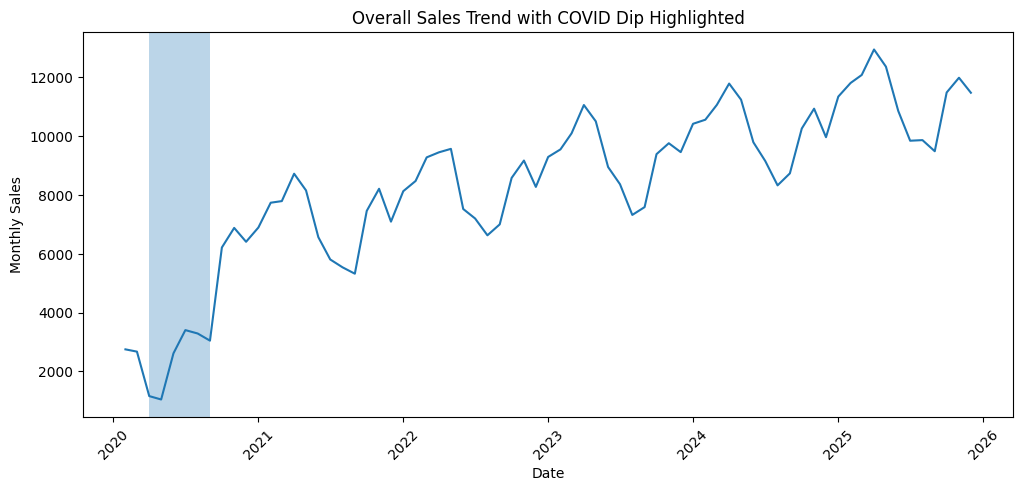

In [17]:
covid_view = df.groupby("Date")["Monthly_Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(covid_view.index, covid_view.values)
plt.axvspan(pd.to_datetime("2020-04-01"), pd.to_datetime("2020-09-01"), alpha=0.3)
plt.title("Overall Sales Trend with COVID Dip Highlighted")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.show()

| Product               | Category | Baseline Model | Baseline MAPE | Exogenous Model | Exogenous MAPE | Final Model |
| --------------------- | -------- | -------------: | ------------: | --------------- | -------------: | ----------- |
| Tractor Linkage Balls | Tractor  |         SARIMA |          3.79 | SARIMAX         |           5.06 | SARIMA      |
| CNC Machine Parts     | CNC      |          ARIMA |          5.23 | ARIMAX          |           3.89 | ARIMAX      |
